In [39]:
import pandas as pd
import seaborn as s
import matplotlib.pyplot as plt

In [40]:
df=pd.read_csv(r"C:\Users\hp\Downloads\Sentiment.csv")
df

,customer_id,gender,age_group,region,product_category,purchase_channel,platform,customer_rating,review_text,sentiment,response_time_hours,issue_resolved,complaint_registered
0,1,male,60+,north,automobile,online,flipkart,1,very disappointed with the quality.,negative,46,yes,yes
1,2,other,46-60,central,books,online,swiggy instamart,5,fast delivery and great packaging.,positive,5,yes,no
2,3,female,36-45,east,sports,online,facebook marketplace,1,very disappointed with the quality.,negative,38,yes,yes
3,4,female,18-25,central,groceries,online,zepto,2,product stopped working after few days.,negative,16,yes,yes
4,5,female,18-25,east,electronics,online,croma,3,neutral about the quality.,neutral,15,yes,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...
24995,24996,female,36-45,south,beauty,online,lenskart,1,very disappointed with the quality.,negative,40,yes,yes
24996,24997,other,60+,central,automobile,online,flipkart,5,"amazing experience, highly recommend!",positive,25,yes,no
24997,24998,male,18-25,south,beauty,online,ajio,4,fast delivery and great packaging.,positive,9,yes,no
24998,24999,female,26-35,central,automobile,online,snapdeal,5,great value for money.,positive,65,no,no


In [41]:
df['platform'].unique()#ignore

array(['flipkart', 'swiggy instamart', 'facebook marketplace', 'zepto',
       'croma', 'amazon', 'shopclues', 'tata cliq', 'snapdeal',
       'paytm mall', 'ajio', 'myntra', 'nykaa', 'reliance digital',
       'meesho', 'bigbasket', 'lenskart', 'jiomart', 'others', 'boat'],
      dtype=object)

In [42]:
df['product_category'].unique()#ignore

array(['automobile', 'books', 'sports', 'groceries', 'electronics',
       'travel', 'fashion', 'home & kitchen', 'beauty'], dtype=object)

In [43]:
df.sort_values(['product_category','customer_rating'],ascending=[True,False]).groupby('product_category').head(3)
#The top 3 customers with the highest rating within each product category based on criteria

,customer_id,gender,age_group,region,product_category,purchase_channel,platform,customer_rating,review_text,sentiment,response_time_hours,issue_resolved,complaint_registered
61,62,other,18-25,central,automobile,online,lenskart,5,"amazing experience, highly recommend!",positive,17,yes,no
182,183,female,60+,east,automobile,online,bigbasket,5,great value for money.,positive,5,yes,no
225,226,male,18-25,east,automobile,online,boat,5,excellent product! exceeded expectations.,positive,32,yes,no
9,10,male,36-45,east,beauty,online,croma,5,great value for money.,positive,56,no,no
59,60,other,18-25,north,beauty,online,jiomart,5,excellent product! exceeded expectations.,positive,58,no,no
169,170,male,46-60,west,beauty,online,tata cliq,5,fast delivery and great packaging.,positive,19,yes,no
1,2,other,46-60,central,books,online,swiggy instamart,5,fast delivery and great packaging.,positive,5,yes,no
21,22,female,18-25,south,books,online,reliance digital,5,excellent product! exceeded expectations.,positive,31,yes,no
96,97,male,36-45,north,books,online,amazon,5,fast delivery and great packaging.,positive,43,yes,no
25,26,female,26-35,central,electronics,online,snapdeal,5,"amazing experience, highly recommend!",positive,61,no,no


In [44]:
#finding number of response on the basis of sentiment within each product categroy
df.groupby(['product_category', 'sentiment']).size()


product_category  sentiment
automobile        negative     1126
                  neutral       583
                  positive     1124
beauty            negative     1104
                  neutral       537
                  positive     1049
books             negative     1141
                  neutral       583
                  positive     1088
electronics       negative     1061
                  neutral       545
                  positive     1119
fashion           negative     1148
                  neutral       534
                  positive     1100
groceries         negative     1108
                  neutral       585
                  positive     1165
home & kitchen    negative     1134
                  neutral       533
                  positive     1059
sports            negative     1049
                  neutral       553
                  positive     1161
travel            negative     1066
                  neutral       632
                  positive     1113


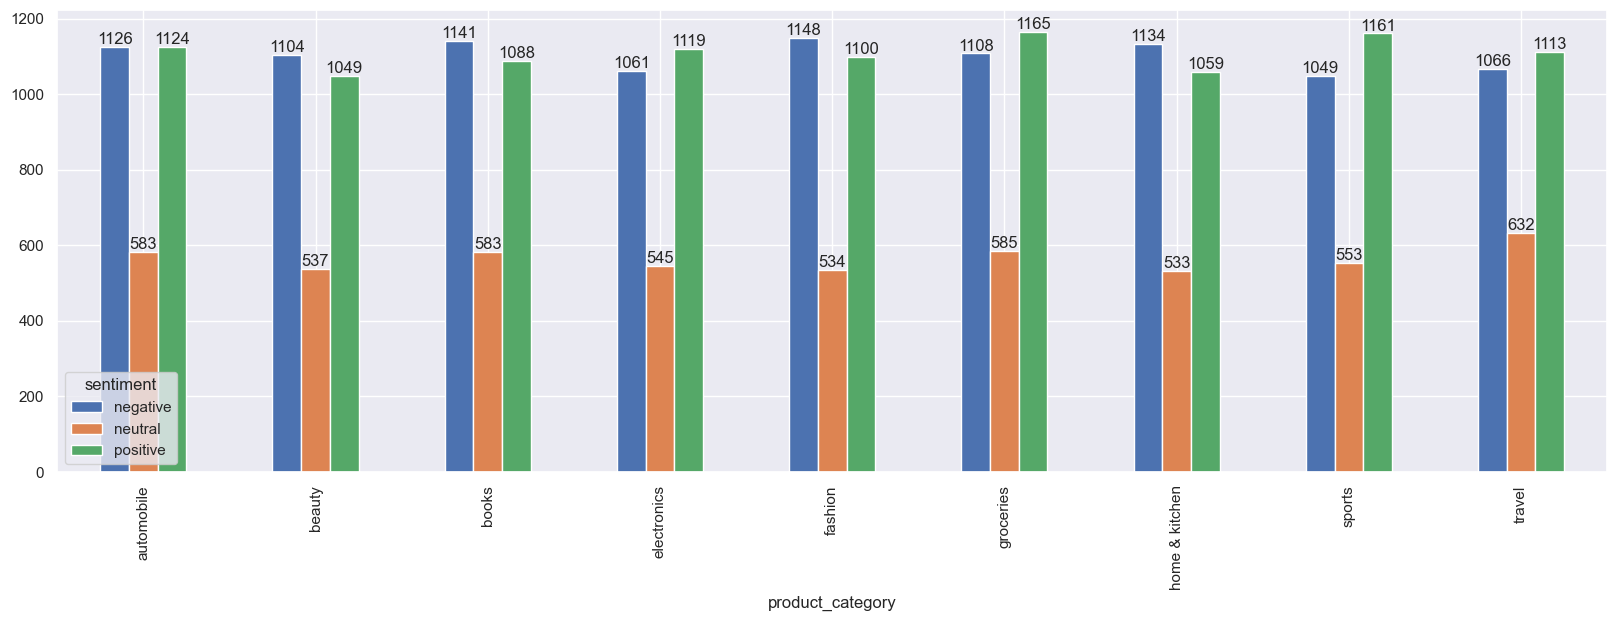

In [45]:
count_sentiment=df.groupby(['product_category', 'sentiment']).size().reset_index(name='count')
a=count_sentiment.pivot(index="product_category",columns='sentiment',values='count')
ax=a.plot(kind='bar',figsize=(20,6))
for i in ax.containers:
    ax.bar_label(i,fmt='%d')
plt.show()


In [46]:
df['sentiment'].unique()#ignore

array(['negative', 'positive', 'neutral'], dtype=object)

In [47]:
df[['customer_id', 'region', 'customer_rating']].head(8)

,customer_id,region,customer_rating
0,1,north,1
1,2,central,5
2,3,east,1
3,4,central,2
4,5,east,3
5,6,central,5
6,7,south,4
7,8,east,5


In [48]:
#percentage of sales on the reional basis
df['region'].value_counts(normalize=True) * 100


region
west       20.324
south      20.088
east       20.004
north      19.852
central    19.732
Name: proportion, dtype: float64

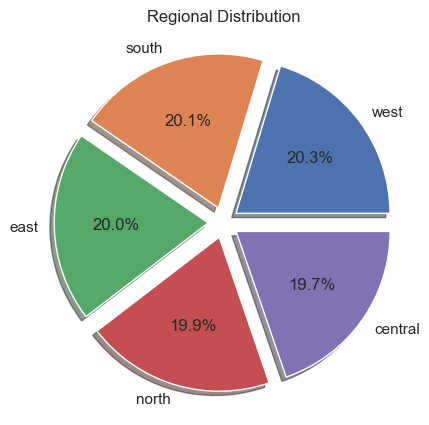

In [50]:
explode=[0.1,0.1,0.1,0.1,0.1]
counting=df['region'].value_counts(normalize=True)*100
counting.plot(kind='pie',autopct='%1.1f%%',explode=explode,shadow=True)
plt.ylabel('')
plt.title('Regional Distribution')
plt.show()



In [ ]:
#sorting values first based on rating and region in descending order
df.sort_values(['customer_rating','region'],ascending=[False,False]).groupby('region').head(2)

,customer_id,gender,age_group,region,product_category,purchase_channel,platform,customer_rating,review_text,sentiment,response_time_hours,issue_resolved,complaint_registered
36,37,other,36-45,west,fashion,online,ajio,5,"amazing experience, highly recommend!",positive,15,yes,no
46,47,female,46-60,west,home & kitchen,online,bigbasket,5,excellent product! exceeded expectations.,positive,6,yes,no
20,21,female,60+,south,sports,online,nykaa,5,"amazing experience, highly recommend!",positive,51,no,no
21,22,female,18-25,south,books,online,reliance digital,5,excellent product! exceeded expectations.,positive,31,yes,no
59,60,other,18-25,north,beauty,online,jiomart,5,excellent product! exceeded expectations.,positive,58,no,no
96,97,male,36-45,north,books,online,amazon,5,fast delivery and great packaging.,positive,43,yes,no
7,8,other,60+,east,fashion,online,swiggy instamart,5,excellent product! exceeded expectations.,positive,53,no,no
9,10,male,36-45,east,beauty,online,croma,5,great value for money.,positive,56,no,no
1,2,other,46-60,central,books,online,swiggy instamart,5,fast delivery and great packaging.,positive,5,yes,no
5,6,other,26-35,central,sports,online,facebook marketplace,5,"amazing experience, highly recommend!",positive,10,yes,no


In [ ]:
'''p=df.groupby(['product_category','customer_id','customer_rating']).head(3)
p'''
df.sort_values('customer_rating',ascending=False).groupby(['product_category','customer_id','customer_rating']).head(3)
#sorting values on the basis of criteria given 

,customer_id,gender,age_group,region,product_category,purchase_channel,platform,customer_rating,review_text,sentiment,response_time_hours,issue_resolved,complaint_registered
5,6,other,26-35,central,sports,online,facebook marketplace,5,"amazing experience, highly recommend!",positive,10,yes,no
7,8,other,60+,east,fashion,online,swiggy instamart,5,excellent product! exceeded expectations.,positive,53,no,no
24998,24999,female,26-35,central,automobile,online,snapdeal,5,great value for money.,positive,65,no,no
1,2,other,46-60,central,books,online,swiggy instamart,5,fast delivery and great packaging.,positive,5,yes,no
24994,24995,female,26-35,north,books,online,nykaa,5,great value for money.,positive,61,no,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...
7540,7541,female,46-60,south,travel,online,others,1,very disappointed with the quality.,negative,28,yes,yes
7535,7536,female,18-25,north,sports,online,meesho,1,product stopped working after few days.,negative,1,yes,yes
7534,7535,male,60+,central,automobile,online,bigbasket,1,not worth the price.,negative,15,yes,yes
2,3,female,36-45,east,sports,online,facebook marketplace,1,very disappointed with the quality.,negative,38,yes,yes


In [ ]:
df['region'].value_counts()
#counting values based on region

region
west       5081
south      5022
east       5001
north      4963
central    4933
Name: count, dtype: int64

In [ ]:
#to find the mean based on gender than region
df.groupby(['gender','region'])['customer_rating'].mean()


gender  region 
female  central    3.077113
        east       2.992583
        north      3.007541
        south      2.949360
        west       2.937910
male    central    3.000596
        east       3.037212
        north      2.992670
        south      3.025150
        west       2.958992
other   central    3.036108
        east       3.002959
        north      3.048689
        south      3.000612
        west       2.976457
Name: customer_rating, dtype: float64

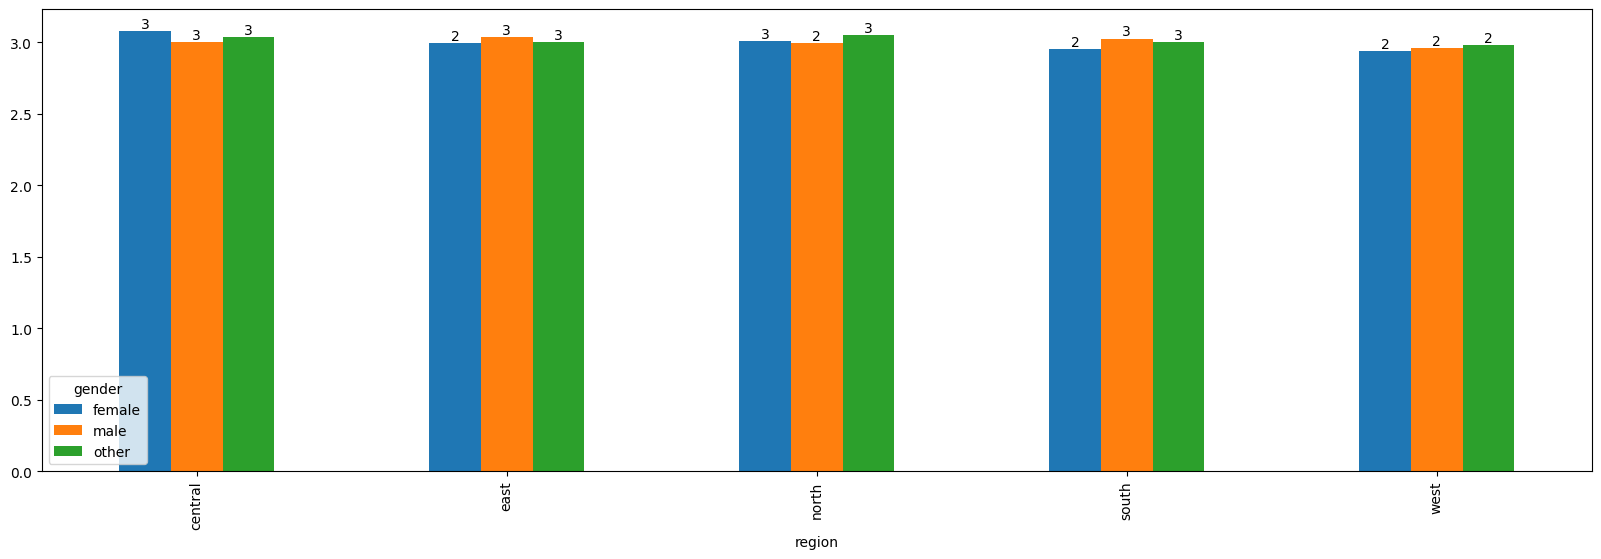

In [ ]:
avg_rating=df.groupby(['gender','region'])['customer_rating'].mean().reset_index()
a=avg_rating.pivot(index="region",columns='gender',values='customer_rating')
ax=a.plot(kind='bar',figsize=(20,6))
for i in ax.containers:
    ax.bar_label(i,fmt='%d')
plt.show()


In [ ]:
#Applying lambda function based on customer rating either high or low
df["customer_rating"].apply(
    lambda x: "High" if x >= 4 
          else "Low")

0         Low
1        High
2         Low
3         Low
4         Low
         ... 
24995     Low
24996    High
24997    High
24998    High
24999     Low
Name: customer_rating, Length: 25000, dtype: object

In [ ]:
df.groupby(['product_category', 'sentiment']).size()
#it will count each sentiment in each product category

product_category  sentiment
automobile        negative     1126
                  neutral       583
                  positive     1124
beauty            negative     1104
                  neutral       537
                  positive     1049
books             negative     1141
                  neutral       583
                  positive     1088
electronics       negative     1061
                  neutral       545
                  positive     1119
fashion           negative     1148
                  neutral       534
                  positive     1100
groceries         negative     1108
                  neutral       585
                  positive     1165
home & kitchen    negative     1134
                  neutral       533
                  positive     1059
sports            negative     1049
                  neutral       553
                  positive     1161
travel            negative     1066
                  neutral       632
                  positive     1113


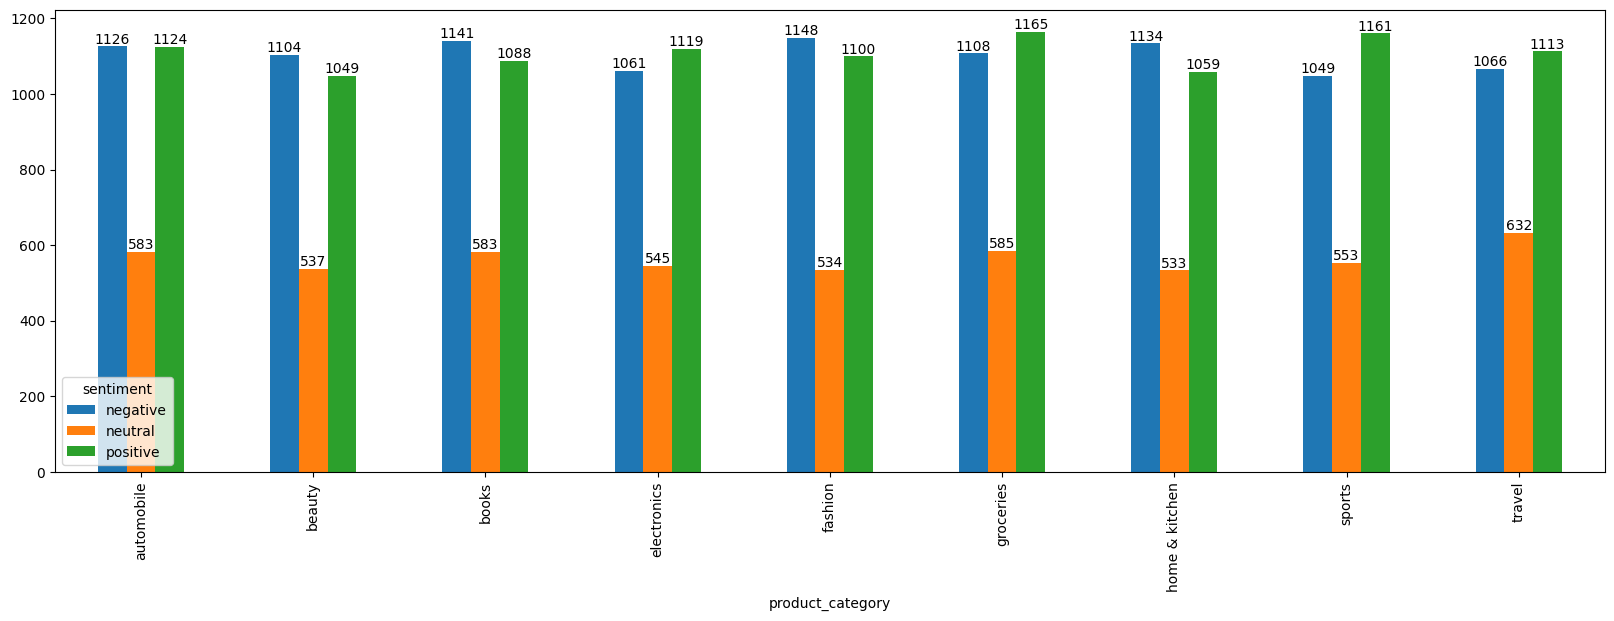

In [ ]:
senitment_count=df.groupby(['product_category','sentiment']).size().reset_index(name='count')
a=senitment_count.pivot(index="product_category",columns='sentiment',values='count')
ax=a.plot(kind='bar',figsize=(20,6))
for i in ax.containers:
    ax.bar_label(i,fmt='%d')
plt.show()


In [ ]:
df[df['sentiment']=='negative'].groupby('product_category').size()
#it will count number of negative sentiment in each product category

product_category
automobile        1126
beauty            1104
books             1141
electronics       1061
fashion           1148
groceries         1108
home & kitchen    1134
sports            1049
travel            1066
dtype: int64

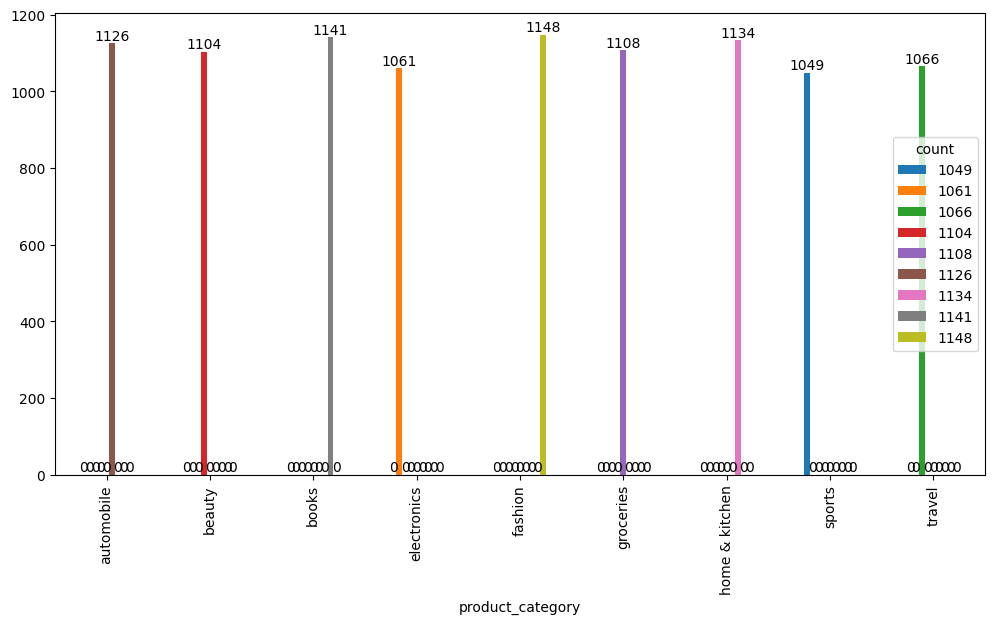

In [ ]:
product_count=df[df['sentiment']=='negative'].groupby('product_category').size().reset_index(name='count')
a=product_count.pivot(index="product_category",columns='count',values='count')
ax=a.plot(kind='bar',figsize=(12,6))
for i in ax.containers:
    ax.bar_label(i,fmt='%d')
plt.show()


In [ ]:
df.columns

Index(['customer_id', 'gender', 'age_group', 'region', 'product_category',
       'purchase_channel', 'platform', 'customer_rating', 'review_text',
       'sentiment', 'response_time_hours', 'issue_resolved',
       'complaint_registered'],
      dtype='object')

<Axes: xlabel='product_category', ylabel='count'>

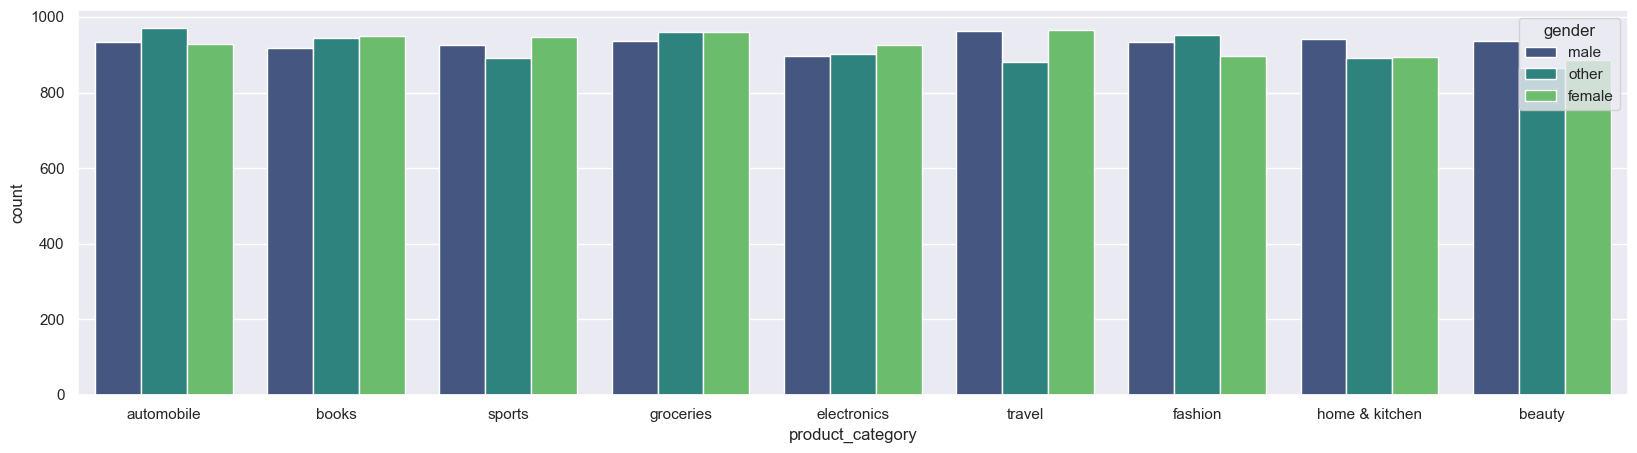

In [ ]:
s.set(rc={'figure.figsize':(2*10,5)})
s.countplot(x = 'product_category',data = df,hue='gender',palette='viridis')

<Axes: xlabel='sentiment', ylabel='count'>

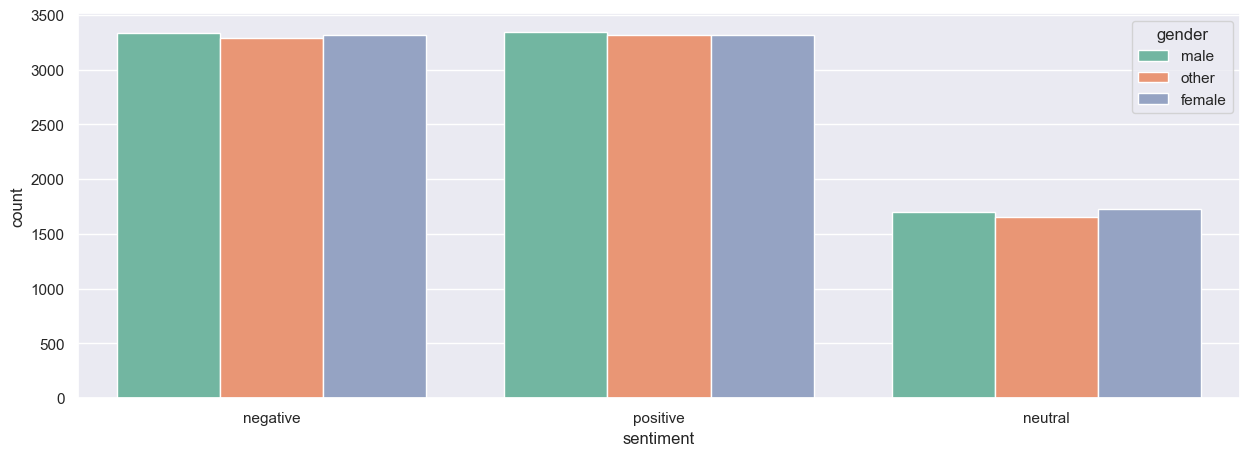

In [ ]:
s.set(rc={'figure.figsize':(1.5*10,5)})
s.countplot(x = 'sentiment',data = df,hue='gender',palette='Set2')

In [ ]:
df.groupby('sentiment').value_counts()

sentiment  customer_id  gender  age_group  region   product_category  purchase_channel  platform              customer_rating  review_text                              response_time_hours  issue_resolved  complaint_registered
negative   1            male    60+        north    automobile        online            flipkart              1                very disappointed with the quality.      46                   yes             yes                     1
           3            female  36-45      east     sports            online            facebook marketplace  1                very disappointed with the quality.      38                   yes             yes                     1
           4            female  18-25      central  groceries         online            zepto                 2                product stopped working after few days.  16                   yes             yes                     1
           11           female  26-35      south    beauty            online     

In [ ]:
df.groupby('gender').max()

,customer_id,age_group,region,product_category,purchase_channel,platform,customer_rating,review_text,sentiment,response_time_hours,issue_resolved,complaint_registered
gender,,,,,,,,,,,,
female,24999,60+,west,travel,online,zepto,5,works fine but could be better.,positive,71,yes,yes
male,25000,60+,west,travel,online,zepto,5,works fine but could be better.,positive,71,yes,yes
other,24997,60+,west,travel,online,zepto,5,works fine but could be better.,positive,71,yes,yes


In [ ]:
df.groupby('gender').min()

,customer_id,age_group,region,product_category,purchase_channel,platform,customer_rating,review_text,sentiment,response_time_hours,issue_resolved,complaint_registered
gender,,,,,,,,,,,,
female,3,18-25,central,automobile,online,ajio,1,"amazing experience, highly recommend!",negative,1,no,no
male,1,18-25,central,automobile,online,ajio,1,"amazing experience, highly recommend!",negative,1,no,no
other,2,18-25,central,automobile,online,ajio,1,"amazing experience, highly recommend!",negative,1,no,no


In [ ]:
df.groupby('platform').min()

,customer_id,gender,age_group,region,product_category,purchase_channel,customer_rating,review_text,sentiment,response_time_hours,issue_resolved,complaint_registered
platform,,,,,,,,,,,,
ajio,18,female,18-25,central,automobile,online,1,"amazing experience, highly recommend!",negative,1,no,no
amazon,7,female,18-25,central,automobile,online,1,"amazing experience, highly recommend!",negative,1,no,no
bigbasket,38,female,18-25,central,automobile,online,1,"amazing experience, highly recommend!",negative,1,no,no
boat,95,female,18-25,central,automobile,online,1,"amazing experience, highly recommend!",negative,1,no,no
croma,5,female,18-25,central,automobile,online,1,"amazing experience, highly recommend!",negative,1,no,no
facebook marketplace,3,female,18-25,central,automobile,online,1,"amazing experience, highly recommend!",negative,1,no,no
flipkart,1,female,18-25,central,automobile,online,1,"amazing experience, highly recommend!",negative,1,no,no
jiomart,60,female,18-25,central,automobile,online,1,"amazing experience, highly recommend!",negative,1,no,no
lenskart,44,female,18-25,central,automobile,online,1,"amazing experience, highly recommend!",negative,1,no,no


In [ ]:
df[df['gender'] == 'male']


,customer_id,gender,age_group,region,product_category,purchase_channel,platform,customer_rating,review_text,sentiment,response_time_hours,issue_resolved,complaint_registered
0,1,male,60+,north,automobile,online,flipkart,1,very disappointed with the quality.,negative,46,yes,yes
6,7,male,36-45,south,travel,online,amazon,4,great value for money.,positive,38,yes,no
8,9,male,18-25,south,home & kitchen,online,shopclues,3,"product is okay, nothing special.",neutral,7,yes,no
9,10,male,36-45,east,beauty,online,croma,5,great value for money.,positive,56,no,no
17,18,male,60+,west,books,online,ajio,3,neutral about the quality.,neutral,32,yes,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...
24983,24984,male,46-60,east,groceries,online,paytm mall,5,"amazing experience, highly recommend!",positive,58,no,no
24990,24991,male,46-60,north,fashion,online,jiomart,1,not worth the price.,negative,69,no,yes
24992,24993,male,60+,north,beauty,online,croma,3,neutral about the quality.,neutral,38,yes,no
24997,24998,male,18-25,south,beauty,online,ajio,4,fast delivery and great packaging.,positive,9,yes,no


In [ ]:
df["rating_category"] = df["customer_rating"].apply(
    lambda x: "High" if x >= 4 
    else ("Medium" if x == 3 
          else "Low")
)
df.head(10)
#rating_category to create a category as high ,low and medium

,customer_id,gender,age_group,region,product_category,purchase_channel,platform,customer_rating,review_text,sentiment,response_time_hours,issue_resolved,complaint_registered,rating_category
0,1,male,60+,north,automobile,online,flipkart,1,very disappointed with the quality.,negative,46,yes,yes,Low
1,2,other,46-60,central,books,online,swiggy instamart,5,fast delivery and great packaging.,positive,5,yes,no,High
2,3,female,36-45,east,sports,online,facebook marketplace,1,very disappointed with the quality.,negative,38,yes,yes,Low
3,4,female,18-25,central,groceries,online,zepto,2,product stopped working after few days.,negative,16,yes,yes,Low
4,5,female,18-25,east,electronics,online,croma,3,neutral about the quality.,neutral,15,yes,no,Medium
5,6,other,26-35,central,sports,online,facebook marketplace,5,"amazing experience, highly recommend!",positive,10,yes,no,High
6,7,male,36-45,south,travel,online,amazon,4,great value for money.,positive,38,yes,no,High
7,8,other,60+,east,fashion,online,swiggy instamart,5,excellent product! exceeded expectations.,positive,53,no,no,High
8,9,male,18-25,south,home & kitchen,online,shopclues,3,"product is okay, nothing special.",neutral,7,yes,no,Medium
9,10,male,36-45,east,beauty,online,croma,5,great value for money.,positive,56,no,no,High


In [ ]:
import numpy as np

df["rating_category"] = np.where(
    df["customer_rating"] >= 4, "High",
    np.where(df["customer_rating"] == 3, "Medium", "Low")
)
df
#rating_category to create a category as high ,low and medium

,customer_id,gender,age_group,region,product_category,purchase_channel,platform,customer_rating,review_text,sentiment,response_time_hours,issue_resolved,complaint_registered,rating_category
0,1,male,60+,north,automobile,online,flipkart,1,very disappointed with the quality.,negative,46,yes,yes,Low
1,2,other,46-60,central,books,online,swiggy instamart,5,fast delivery and great packaging.,positive,5,yes,no,High
2,3,female,36-45,east,sports,online,facebook marketplace,1,very disappointed with the quality.,negative,38,yes,yes,Low
3,4,female,18-25,central,groceries,online,zepto,2,product stopped working after few days.,negative,16,yes,yes,Low
4,5,female,18-25,east,electronics,online,croma,3,neutral about the quality.,neutral,15,yes,no,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24995,24996,female,36-45,south,beauty,online,lenskart,1,very disappointed with the quality.,negative,40,yes,yes,Low
24996,24997,other,60+,central,automobile,online,flipkart,5,"amazing experience, highly recommend!",positive,25,yes,no,High
24997,24998,male,18-25,south,beauty,online,ajio,4,fast delivery and great packaging.,positive,9,yes,no,High
24998,24999,female,26-35,central,automobile,online,snapdeal,5,great value for money.,positive,65,no,no,High


In [ ]:
df.groupby('region')['customer_rating'].mean()


region
central    3.037503
east       3.011198
north      3.015918
south      2.991239
west       2.957882
Name: customer_rating, dtype: float64

In [ ]:
df[df['gender'] == 'male'].groupby('gender').max()


,customer_id,age_group,region,product_category,purchase_channel,platform,customer_rating,review_text,sentiment,response_time_hours,issue_resolved,complaint_registered,rating_category
gender,,,,,,,,,,,,,
male,25000,60+,west,travel,online,zepto,5,works fine but could be better.,positive,71,yes,yes,Medium


In [ ]:
df[df['gender'] == 'male'].groupby('response_time_hours').max()


,customer_id,gender,age_group,region,product_category,purchase_channel,platform,customer_rating,review_text,sentiment,issue_resolved,complaint_registered,rating_category
response_time_hours,,,,,,,,,,,,,
1,24948,male,60+,west,travel,online,zepto,5,works fine but could be better.,positive,yes,yes,Medium
2,24966,male,60+,west,travel,online,zepto,5,works fine but could be better.,positive,yes,yes,Medium
3,24928,male,60+,west,travel,online,zepto,5,works fine but could be better.,positive,yes,yes,Medium
4,24857,male,60+,west,travel,online,zepto,5,works fine but could be better.,positive,yes,yes,Medium
5,24710,male,60+,west,travel,online,zepto,5,works fine but could be better.,positive,yes,yes,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...
67,25000,male,60+,west,travel,online,zepto,5,works fine but could be better.,positive,no,yes,Medium
68,24775,male,60+,west,travel,online,zepto,5,works fine but could be better.,positive,no,yes,Medium
69,24991,male,60+,west,travel,online,zepto,5,works fine but could be better.,positive,no,yes,Medium


In [ ]:
df.sort_values(['region', 'age_group'], ascending=[True, True])


,customer_id,gender,age_group,region,product_category,purchase_channel,platform,customer_rating,review_text,sentiment,response_time_hours,issue_resolved,complaint_registered,rating_category
3,4,female,18-25,central,groceries,online,zepto,2,product stopped working after few days.,negative,16,yes,yes,Low
50,51,other,18-25,central,books,online,reliance digital,4,"amazing experience, highly recommend!",positive,9,yes,no,High
61,62,other,18-25,central,automobile,online,lenskart,5,"amazing experience, highly recommend!",positive,17,yes,no,High
97,98,other,18-25,central,sports,online,flipkart,2,very disappointed with the quality.,negative,1,yes,yes,Low
216,217,male,18-25,central,books,online,ajio,1,very disappointed with the quality.,negative,54,no,yes,Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24946,24947,other,60+,west,groceries,online,myntra,5,very satisfied with the quality.,positive,67,no,no,High
24950,24951,female,60+,west,electronics,online,others,1,late delivery and poor packaging.,negative,47,yes,yes,Low
24962,24963,other,60+,west,groceries,online,facebook marketplace,2,product stopped working after few days.,negative,67,no,yes,Low
24981,24982,male,60+,west,travel,online,lenskart,5,excellent product! exceeded expectations.,positive,10,yes,no,High


In [ ]:
df.sort_values('age_group')


,customer_id,gender,age_group,region,product_category,purchase_channel,platform,customer_rating,review_text,sentiment,response_time_hours,issue_resolved,complaint_registered,rating_category
23115,23116,other,18-25,west,home & kitchen,online,croma,5,fast delivery and great packaging.,positive,45,yes,no,High
9043,9044,female,18-25,west,travel,online,croma,3,average experience overall.,neutral,54,no,no,Medium
3652,3653,female,18-25,central,sports,online,shopclues,2,very disappointed with the quality.,negative,8,yes,yes,Low
12250,12251,male,18-25,east,travel,online,lenskart,1,product stopped working after few days.,negative,7,yes,yes,Low
23198,23199,other,18-25,central,travel,online,ajio,4,excellent product! exceeded expectations.,positive,34,yes,no,High
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9817,9818,other,60+,north,automobile,online,amazon,2,not worth the price.,negative,5,yes,yes,Low
9818,9819,female,60+,central,automobile,online,shopclues,4,"amazing experience, highly recommend!",positive,47,yes,no,High
9820,9821,other,60+,south,sports,online,tata cliq,1,very disappointed with the quality.,negative,53,no,yes,Low
9844,9845,other,60+,south,beauty,online,croma,2,very disappointed with the quality.,negative,3,yes,yes,Low


In [ ]:
high_rating = df[df['customer_rating'] > 4][['customer_id', 'product_category', 'customer_rating']]
high_rating
#it will filter out the rating higher than 4 and load it into new data frame call 'high_rating'

,customer_id,product_category,customer_rating
1,2,books,5
5,6,sports,5
7,8,fashion,5
9,10,beauty,5
12,13,fashion,5
...,...,...,...
24987,24988,electronics,5
24993,24994,books,5
24994,24995,books,5
24996,24997,automobile,5
